# 19 — DLM clássico sem spline: lags 1..10

Extensão solicitada em 05/10/2026; anterior preservado. α=0,05, ΔI, painel 27 UF. Protocolo registrado antes da execução. Não executar Granger/SARIMAX. Cada coeficiente de lag é livre.

## 1. Objetivo e reprodução

Pergunta: associação entre exposição passada e ΔI. Modelos reais foram executados pelo módulo antes deste notebook. Por padrão, o notebook inspeciona saídas e reestima verificações representativas; para recalcular tudo, RUN_ANALYSIS=True exige Python/R instalados. Não fabrica outputs.

In [1]:
from pathlib import Path
import sys, pandas as pd, numpy as np
from threadpoolctl import threadpool_limits
ROOT=Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0,str(ROOT/"src"))
import dlm_classico as c
RUN_ANALYSIS=False
if RUN_ANALYSIS: c.run()
OUT=c.OUT
print((ROOT/"docs/dlm_classico_protocolo.md").read_text())

# DLM clássico, sem spline — protocolo prévio

Registrado em 05/10/2026 antes de novos resultados, por solicitação da autora. Preservar notebooks 16–18, saídas e arquivos anteriores. Uma figura antiga já estava modificada no início desta etapa; não incluí-la nos commits. Não executar Granger ou SARIMAX.

## Pergunta e especificação

Painel é o desenho principal. ΔI em pontos percentuais, UF + mês-ano FE, não ponderado, cobertura municipal relativa C_prop sem log. DLM irrestrito: ΔI_it = α_i + λ_t + Σ(k=1..K) β_k X_i,t-k + ε_it, K=1,...,10. Cada lag tem seu próprio coeficiente: não há spline/Almon. Interpretar '1 a 10' como exclusão do contemporâneo e comparação dos dez horizontes máximos. Principal fixo K10; demais K são sensibilidades, sem seleção por significância. BIC/AIC descritivos em amostra comum usando disponibilidade dos lags até 10. Adicionar somente uma comparação contemporânea 0..10 e uma sensibilidade ΔX com 1..10 por exposição/período. ΔX muda estimando: mudança da exposi

## 2. Bases e chave UF-mês

Painel original preservado. Datas ordenadas e contínuas dentro da UF são necessárias; primeira diferença/lag nunca cruzam unidades.

In [2]:
panel=c.r.load_panel()
assert len(panel)==3888 and not panel.duplicated(["uf","data_base"]).any()
print(panel.groupby("uf").size().describe())

count     27.0
mean     144.0
std        0.0
min      144.0
25%      144.0
50%      144.0
75%      144.0
max      144.0
dtype: float64


## 3. Repetições do Atlas

A preserva 40339 registros. B usa 40238 chaves municipais distintas;101 linhas adicionais não são apagadas da fonte. C é invariante porque conta municípios distintos. Cache de exposição conferido com Atlas completo recuperado e hash da revisão anterior.

In [3]:
display(pd.read_csv(OUT/"auditoria_chaves.csv"))
display(pd.read_csv(OUT/"reconciliacao_atlas.csv"))

,A,B,repeticoes_chave,C_invariante,regra
0,40339,40238,101,True,UF + IBGE município + data evento + COBRADE; k...


,coluna,A_total,cobertura_cache_igual_atlas
0,total_desastres,40339,True
1,grupo_climatologico,19518,True
2,grupo_hidrologico,15409,True
3,grupo_meteorologico,3716,True
4,grupo_outros,1696,True
5,tipo_alagamentos,1504,True
6,tipo_chuvas_intensas,8084,True
7,tipo_doencas_infecciosas,243,True
8,tipo_enxurradas,2759,True
9,tipo_erosao,480,True


## 4. Estacionariedade da dependente

ΔI é a mudança mensal em pontos percentuais. CIPS preservado favorece ΔI, enquanto nível é sensível a determinísticos/período. p=0,01 é saída limitada da tabela, não número exato.

In [4]:
display(pd.read_csv(OUT/"cips_dependente_preservado.csv"))

,periodo,serie,deterministico,lags,CIPS,p,N,T
0,Total,taxa_inadimplencia,drift,1,-2.254054,0.028125,27,144
1,Total,taxa_inadimplencia,drift,2,-2.291687,0.017723,27,144
2,Total,taxa_inadimplencia,trend,1,-1.882181,0.100000,27,144
3,Total,taxa_inadimplencia,trend,2,-1.783215,0.100000,27,144
4,Total,delta,drift,1,-6.172200,0.010000,27,143
5,Total,delta,drift,2,-5.645215,0.010000,27,143
6,Pré,taxa_inadimplencia,drift,1,-2.148554,0.063257,27,85
7,Pré,taxa_inadimplencia,drift,2,-2.048473,0.100000,27,85
8,Pré,taxa_inadimplencia,trend,1,-2.354220,0.100000,27,85
9,Pré,taxa_inadimplencia,trend,2,-2.275085,0.100000,27,85


## 5. Estacionariedade das exposições

CIPS anterior foi indisponível: não certificou exposição. ADF intercepto/maxlag 3/BIC + KPSS intercepto/auto por UF são complementares. Constantes e falhas numéricas ficam indisponíveis. ΔX é sensibilidade, sem diferenciar repetidamente ou escolher pelo menor p.

In [5]:
station=pd.read_csv(OUT/"estacionariedade_resumo.csv")
display(station[station.serie.isin(["I","total_desastres","tipo_onda_de_frio"])])
display(pd.read_csv(OUT/"cips_exposicoes_preservado.csv"))

,periodo,serie,transformacao,UFs,calculaveis,concordantes,fracao_todas_ufs
0,Pré,I,delta,27,27,22,0.814815
1,Pré,I,nivel,27,27,1,0.037037
38,Pré,tipo_onda_de_frio,delta,27,2,1,0.037037
39,Pré,tipo_onda_de_frio,nivel,27,2,2,0.074074
48,Pré,total_desastres,delta,27,27,22,0.814815
49,Pré,total_desastres,nivel,27,26,21,0.777778
50,Total,I,delta,27,27,26,0.962963
51,Total,I,nivel,27,27,5,0.185185
88,Total,tipo_onda_de_frio,delta,27,3,2,0.074074
89,Total,tipo_onda_de_frio,nivel,27,4,4,0.148148


,periodo,serie,lags,CIPS,p,status
0,Total,total_desastres,1,NaN,NaN,não calculável: UF com série constante ou quas...
1,Total,total_desastres,2,NaN,NaN,não calculável: UF com série constante ou quas...
2,Total,grupo_climatologico,1,NaN,NaN,não calculável: UF com série constante ou quas...
3,Total,grupo_climatologico,2,NaN,NaN,não calculável: UF com série constante ou quas...
4,Total,grupo_hidrologico,1,NaN,NaN,não calculável: UF com série constante ou quas...
5,Total,grupo_hidrologico,2,NaN,NaN,não calculável: UF com série constante ou quas...
6,Total,grupo_meteorologico,1,NaN,NaN,não calculável: UF com série constante ou quas...
7,Total,grupo_meteorologico,2,NaN,NaN,não calculável: UF com série constante ou quas...
8,Pré,total_desastres,1,NaN,NaN,não calculável: UF com série constante ou quas...
9,Pré,total_desastres,2,NaN,NaN,não calculável: UF com série constante ou quas...


## 6. Construção clássica dos lags

Lags 1..K, K 1..10, sem contemporâneo principal. Cada lag é um regressor livre. FE removem choques comuns e diferenças permanentes; identificação relativa entre UFs.

In [6]:
ex=c.r.get_exps()
q=c.ordered_lags(panel,ex["total_desastres"]["C_prop"])
display(q[["uf","data_base","y","x1","x10"]].head(14))

,uf,data_base,y,x1,x10
0,AC,2013-01-01,NaN,NaN,NaN
1,AC,2013-02-01,-0.028367,0.000000,NaN
2,AC,2013-03-01,-0.015677,0.000000,NaN
3,AC,2013-04-01,0.161833,0.045455,NaN
4,AC,2013-05-01,0.071807,0.090909,NaN
5,AC,2013-06-01,-0.319484,0.000000,NaN
6,AC,2013-07-01,-0.110129,0.227273,NaN
7,AC,2013-08-01,-0.038726,0.000000,NaN
8,AC,2013-09-01,0.223861,0.000000,NaN
9,AC,2013-10-01,0.006078,0.000000,NaN


## 7. Grade e amostra comum

Disponibilidade de ΔXlag 10 fixa primeira resposta emdez 2013;3591 UF-mês total e 1998 pré. TodosKcomparáveis na mesma amostra. PrincipalK 10; BICdescritivo não mede duração.

In [7]:
models=pd.read_csv(OUT/"modelos.csv")
display(models.groupby(["especificacao","K"]).size().rename("modelos").reset_index())
display(models[["periodo","N","data_inicio","data_fim"]].drop_duplicates())

,especificacao,K,modelos
0,Com contemporâneo,10,46
1,Delta X,10,46
2,Principal,1,46
3,Principal,2,46
4,Principal,3,46
5,Principal,4,46
6,Principal,5,46
7,Principal,6,46
8,Principal,7,46
9,Principal,8,46


,periodo,N,data_inicio,data_fim
0,Total,3591,2013-12-01,2024-12-01
288,Pré,1998,2013-12-01,2020-01-01


## 8. Estimação livre e matriz

Verificação representativa reestima modeloK 10 de Total. Soma calculada com matriz completa. O módulo não chama base spline para esses modelos.

In [8]:
with threadpool_limits(limits=1):
 f=c.fit(q[q.data_base>=pd.Timestamp("2013-12-01")],10)
print("Coeficientes livres", f["b"])
print("Acumulado", f["b"].sum(), "SE", np.sqrt(f["V"].sum()))
assert np.isclose(f["b"].sum(),models[(models.periodo=="Total")&(models.coluna=="total_desastres")&(models.especificacao=="Principal")&(models.K==10)].acumulado_estimate.iloc[0])

Coeficientes livres [ 0.02277561  0.01417913  0.0089072   0.00852649 -0.01563718 -0.02076271
 -0.01825757  0.01112543 -0.00106428  0.01043669]
Acumulado 0.02022881765748279 SE 0.04962757229661634


## 9. Resultados e multiplicidade

α0,05 aplica-se a pnominal e qBH separadamente.48 hipóteses porK/endpoint egrade 480 exploratória. Não procurar o menor p entreK.

In [9]:
main=models[models.especificacao=="Principal"]
display(main.groupby("K").agg(n=("coluna","size"),acumulado_nominal=("acumulado_p",lambda x:sum(x<.05)),acumulado_BH48=("q_acumulado_p",lambda x:sum(x<.05)),acumulado_BH480=("q_grade_acumulado_p",lambda x:sum(x<.05))))

,n,acumulado_nominal,acumulado_BH48,acumulado_BH480
K,,,,
1,46,7,0,0
2,46,5,0,0
3,46,4,2,2
4,46,5,2,2
5,46,3,2,2
6,46,4,1,1
7,46,6,1,1
8,46,8,2,2
9,46,5,2,2


## 10. CR 2 e perfisK 10

CR 2 via clubSandwich, coeficientesPython/R reconciliados. Satterthwaite por contraste; HTZ pode ser indisponível. ICperfil ponto a ponto, sem alegar bandas simultâneas.

In [10]:
cr=pd.read_csv(OUT/"cr2.csv")
display(cr[(cr.especificacao=="Principal")&(cr.endpoint=="acumulado")][["periodo","exposicao","estimate","low","high","p","df","q"]])
print(cr[cr.endpoint=="joint"].groupby("status").size())

status
calculado        23
indisponível    115
dtype: int64


,periodo,exposicao,estimate,low,high,p,df,q
0,Total,Total de desastres,0.020229,-0.092388,0.132845,0.700655,11.212719,0.951156
72,Total,Grupo | Climatológico,0.071549,-0.116932,0.260029,0.425637,12.479102,0.951156
144,Total,Grupo | Hidrológico,-0.061655,-0.251733,0.128423,0.494744,12.566549,0.951156
216,Total,Grupo | Meteorológico,-0.073967,-0.820485,0.672552,0.757140,2.616001,0.951156
288,Total,Grupo | Outros,-0.025853,-0.375186,0.323481,0.675260,1.352379,0.951156
360,Total,Tipologia | Alagamentos,-0.218726,-2.693638,2.256186,0.676338,1.560480,0.951156
432,Total,Tipologia | Chuvas Intensas,-0.206646,-0.478238,0.064945,0.120724,9.895819,0.951156
504,Total,Tipologia | Doenças infecciosas,-0.044790,-2.664718,2.575137,0.898199,1.164121,0.979854
576,Total,Tipologia | Enxurradas,0.363964,-0.487119,1.215047,0.306532,4.232957,0.951156
648,Total,Tipologia | Erosão,0.024329,-0.647606,0.696264,0.777874,1.126273,0.951156


## 11. Bootstrap

Wild bootstrap é inferência do mesmo modelo, não outra relação. Usamos 4.999/9.999 sorteios em K=10, nulo imposto e checagem de rank. Sem suporte suficiente, a inferência pode falhar ou ser imprecisa.

In [11]:
boot=pd.read_csv(OUT/"bootstrap.csv")
display(boot.groupby("endpoint").agg(n=("p","size"),nominal=("p",lambda x:sum(x<.05)),BH=("q_p",lambda x:sum(x<.05))))
display(boot[boot.coluna=="tipo_onda_de_frio"])

,n,nominal,BH
endpoint,,,
acumulado,46,2,0
joint,46,0,0


,periodo,coluna,exposicao,nivel,especificacao,metodo,K,lag_inicio,J,n_parametros_exposicao,FE,medida,transformacao,ponderado,N,meses,ufs,data_inicio,data_fim,AIC,BIC,rank,condition,endpoint,p,mcse,status,singular,B,obs,q_p
32,Total,tipo_onda_de_frio,Tipologia | Onda de Frio,Tipologia,Principal,DLM irrestrito,10,1,NaN,10,UF + mês-ano,C_prop,identidade,False,3591,133,27,2013-12-01,2024-12-01,-16293.903816,-15248.438383,10,1.133831,acumulado,0.2594,0.004383,calculado,0,9999,61.242974,0.894827
33,Total,tipo_onda_de_frio,Tipologia | Onda de Frio,Tipologia,Principal,DLM irrestrito,10,1,NaN,10,UF + mês-ano,C_prop,identidade,False,3591,133,27,2013-12-01,2024-12-01,-16293.903816,-15248.438383,10,1.133831,joint,0.1375,0.003444,calculado,0,9999,537.918295,0.941673
78,Pré,tipo_onda_de_frio,Tipologia | Onda de Frio,Tipologia,Principal,DLM irrestrito,10,1,NaN,10,UF + mês-ano,C_prop,identidade,False,1998,74,27,2013-12-01,2020-01-01,-8348.503604,-7732.514389,10,2.875108,acumulado,0.7027,0.004571,calculado,0,9999,1.852110,0.894827
79,Pré,tipo_onda_de_frio,Tipologia | Onda de Frio,Tipologia,Principal,DLM irrestrito,10,1,NaN,10,UF + mês-ano,C_prop,identidade,False,1998,74,27,2013-12-01,2020-01-01,-8348.503604,-7732.514389,10,2.875108,joint,0.1422,0.003493,calculado,0,9999,233.117639,0.941673


## 12. Suporte, Onda de Frio e Granizo

N_eff da exposição, N_eff por alavancagem/contraste e df CR 2 são objetos distintos. Onda de Frio histórica não é confirmada por esta extensão; classificar com números reais. Granizo comparação com Grangerexistente, semreexecução.

In [12]:
support=pd.read_csv(OUT/"suporte_design.csv")
display(support[(support.especificacao=="Principal")&(support.K==10)&support.coluna.isin(["total_desastres","tipo_onda_de_frio","tipo_granizo"])])

,periodo,coluna,exposicao,nivel,especificacao,metodo,K,lag_inicio,J,n_parametros_exposicao,FE,medida,transformacao,ponderado,N,meses,ufs,data_inicio,data_fim,AIC,BIC,rank,condition,ufs_janela,cells_janela,meses_janela,ufs_x0,neff_leverage,top_leverage,neff_contraste,top1_contraste,top2_contraste,uf_dominante,condition_padronizada,status_suporte,suporte_janela
9,Total,total_desastres,Total de desastres,Total,Principal,DLM irrestrito,10,1,NaN,10,UF + mês-ano,C_prop,identidade,False,3591,133,27,2013-12-01,2024-12-01,-16296.223039,-15250.757606,10,1.361096,27,3440,133,27,14.079121,0.171937,12.112662,0.208235,0.321939,DF,1.337479,suporte mais amplo,cobertura em nível
141,Total,tipo_granizo,Tipologia | Granizo,Tipologia,Principal,DLM irrestrito,10,1,NaN,10,UF + mês-ano,C_prop,identidade,False,3591,133,27,2013-12-01,2024-12-01,-16289.563814,-15244.098380,10,1.243845,16,1052,133,15,4.956395,0.329685,4.941464,0.309860,0.562708,ES,1.243269,altamente concentrado,cobertura em nível
201,Total,tipo_onda_de_frio,Tipologia | Onda de Frio,Tipologia,Principal,DLM irrestrito,10,1,NaN,10,UF + mês-ano,C_prop,identidade,False,3591,133,27,2013-12-01,2024-12-01,-16293.903816,-15248.438383,10,1.133831,10,346,109,10,1.095656,0.955308,1.109752,0.949193,0.956497,MS,1.133825,altamente concentrado,cobertura em nível
297,Pré,total_desastres,Total de desastres,Total,Principal,DLM irrestrito,10,1,NaN,10,UF + mês-ano,C_prop,identidade,False,1998,74,27,2013-12-01,2020-01-01,-8355.810348,-7739.821133,10,1.293285,27,1898,74,27,10.525106,0.182275,11.536230,0.194997,0.317771,DF,1.288253,suporte mais amplo,cobertura em nível
429,Pré,tipo_granizo,Tipologia | Granizo,Tipologia,Principal,DLM irrestrito,10,1,NaN,10,UF + mês-ano,C_prop,identidade,False,1998,74,27,2013-12-01,2020-01-01,-8350.391544,-7734.402328,10,1.415296,14,538,74,13,3.104155,0.534950,4.142902,0.419442,0.601561,RS,1.412547,altamente concentrado,cobertura em nível
477,Pré,tipo_onda_de_frio,Tipologia | Onda de Frio,Tipologia,Principal,DLM irrestrito,10,1,NaN,10,UF + mês-ano,C_prop,identidade,False,1998,74,27,2013-12-01,2020-01-01,-8348.503604,-7732.514389,10,2.875108,6,106,50,5,1.195569,0.913516,1.279554,0.880270,0.961339,MS,2.302523,altamente concentrado,cobertura em nível


## 13. ΔX e contemporâneo

ΔX está na mesma amostra e muda o estimando. O modelo 0..10 verifica sensibilidade contemporânea; β0 não estabelece precedência. Compare estimativas e intervalos sem votação de p-valores.

In [13]:
display(cr[(cr.endpoint=="acumulado")&cr.coluna.isin(["total_desastres","tipo_onda_de_frio","tipo_granizo"])][["periodo","exposicao","especificacao","estimate","low","high","p","q"]])

,periodo,exposicao,especificacao,estimate,low,high,p,q
0,Total,Total de desastres,Principal,0.020229,-0.092388,0.132845,0.700655,0.951156
23,Total,Total de desastres,Com contemporâneo,0.051053,-0.074721,0.176827,0.391825,1.000000
49,Total,Total de desastres,Delta X,0.146290,-0.227959,0.520539,0.404531,0.958759
792,Total,Tipologia | Granizo,Principal,-1.037224,-3.324500,1.250053,0.274017,0.951156
815,Total,Tipologia | Granizo,Com contemporâneo,-0.625545,-2.981197,1.730108,0.497914,1.000000
841,Total,Tipologia | Granizo,Delta X,0.258074,-4.226014,4.742163,0.882058,0.962245
1152,Total,Tipologia | Onda de Frio,Principal,-1.425162,-6.346974,3.496649,0.187534,0.951156
1175,Total,Tipologia | Onda de Frio,Com contemporâneo,-1.326285,-5.870244,3.217674,0.186079,1.000000
1201,Total,Tipologia | Onda de Frio,Delta X,0.850189,-2.631705,4.332083,0.221653,0.958759
1728,Pré,Total de desastres,Principal,-0.071037,-0.175840,0.033767,0.163151,0.951156


## 14. Gráficos

Pergunta: formato incremental eacumuladoK 10. X=lag/horizonte; Y=ppporunidadecobertura; IC 95%CR 2 pontual; zeroindicado. Semcausalidade ou duração pelo último lag significativo.

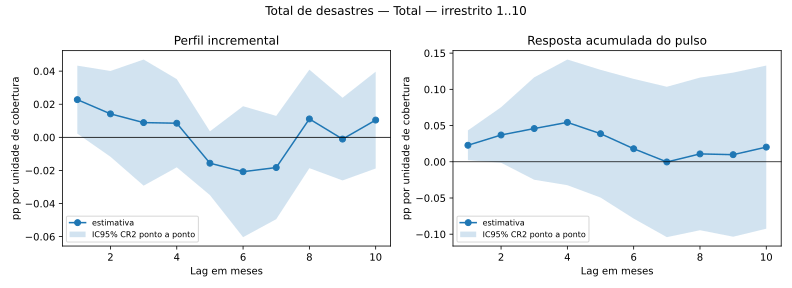

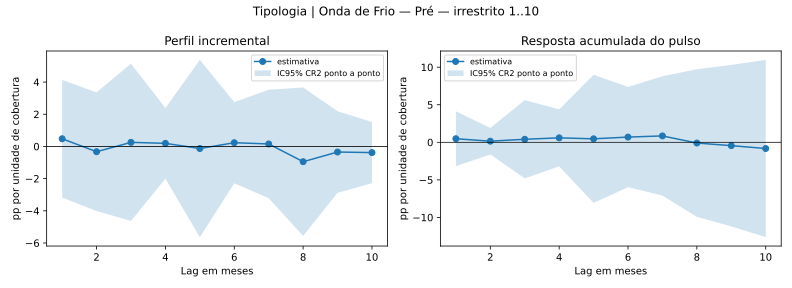

In [14]:
from IPython.display import SVG
display(SVG(filename=str(c.FIG/"Total_total_desastres.svg")))
display(SVG(filename=str(c.FIG/"Pré_tipo_onda_de_frio.svg")))

## 15. Painel versus nacional

Painel: heterogeneidade relativa entre UFs dentro do mês, análise principal. Nacional: taxa 100 ×ΣCI/ΣCA no tempo, complementar, mais vulnerável a confundimento agregado. Não foi refeito aqui. Bootstrap é outro método inferencial do mesmo modelo.

In [15]:
print("Não houve Granger ou SARIMAX nesta etapa. Consulte docs/dlm_classico_resultados.md e o HTML entregue no chat.")

Não houve Granger ou SARIMAX nesta etapa. Consulte docs/dlm_classico_resultados.md e o HTML entregue no chat.


## 16. Testes e conclusão

Testamos propriedades independentes: FE explícitos, FDR, calendário, covariância dos contrastes, rank e parametrização. As conclusões devem seguir o conjunto da evidência.

In [16]:
import verificar_dlm_classico as checks
with threadpool_limits(limits=1):display(checks.verify())
print((ROOT/"docs/dlm_classico_resultados.md").read_text())

# DLM clássico, sem spline: lags de 1 a 10

O protocolo foi registrado em 05/10/2026 antes da estimação (commit f5bd4e6). Esta extensão segue o pedido da autora e preserva notebooks 16–18 e resultados anteriores. Granger e SARIMAX não foram executados. A análise nacional anterior permanece complementar; não foi reestimada nesta etapa.

## Especificação e amostra

Principal: ΔI em pontos percentuais, cobertura municipal relativa em nível, FE de UF e mês-ano, sem ponderação, K=10 e dez coeficientes livres para lags 1–10. Não há spline ou Almon. K=1,...,9 são comparações de horizonte, sem seleção por significância. As sensibilidades K=10 incluem contemporâneo (0–10) e exposição em primeira diferença (ΔX, lags 1–10).

Foram executados 552 modelos: 460 da grade (46 cenários elegíveis × 10), 46 com contemporâneo e 46 com ΔX. Todos utilizam a mesma amostra por exposição/período: dezembro/2013–dezembro/2024, 3.591 UF-mês e 133 meses; ou dezembro/2013–janeiro/2020, 1.998 UF-mês e 74 meses. A di

,teste,ok
0,lag calendário 1,True
1,lag calendário 2,True
2,lag calendário 3,True
3,lag calendário 4,True
4,lag calendário 5,True
5,lag calendário 6,True
6,lag calendário 7,True
7,lag calendário 8,True
8,lag calendário 9,True
9,lag calendário 10,True
